# Sahel cereal yields & climate shocks — main analysis

**How much do drought years reduce millet and sorghum yields across the Sahel,
once the long-run yield trend is removed?**

Millet and sorghum are the primary *subsistence* cereals across the Sahel —
they feed tens of millions of people directly, as food security rather than as
a tradable commodity. The relationship between rainfall variability and yield
is the load-bearing climate-adaptation question for the region, yet the debate
is often dominated by narrative or by single-country case studies. This project
produces a clean, defensible point estimate of the **average drought-year yield
deviation** across six countries — Burkina Faso, Mali, Niger, Senegal, Chad and
Mauritania — with explicit robustness checks.

**Scope.** This is a *descriptive* estimate of an average effect in a small
panel (6 countries × ~64 years). It is **not** a yield forecast, **not** an
attribution of the droughts themselves to climate change, and **not** a source
of country-specific policy recommendations.

**How to read this notebook.** Every load-bearing data-processing choice is
presented as a **five-part decision block** — problem, diagnostic, options,
decision + rationale, sensitivity (see `notebooks/NOTEBOOK_STRUCTURE.md`). No
choice is conventional; each is anchored in a diagnostic on the actual data.
This notebook covers panel assembly and the data/climate decisions
(6, 1, 3); `02_main.ipynb` continues with the estimation decisions and the
event study.

## Part 0 — setup

The analysis reads only built artifacts: the pinned FAOSTAT snapshot and the
raw CRU / GADM / cropland inputs through the `sahel_yields` package. Nothing is
fetched live (see Decision 6).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sahel_yields import data, climate, econ, diagnostics, viz

viz.set_style()
pd.set_option("display.precision", 4)

## Part 1 — FAOSTAT yields

Yields are national annual millet and sorghum yields (kg/ha) for the six Sahel
countries, 1961-2024, from FAOSTAT (domain *Production: Crops and livestock
products*).

In [2]:
fao = data.load_faostat_snapshot()
print(f"snapshot date : {data.SNAPSHOT_DATE}")
print(f"rows          : {len(fao)}  ({fao.iso3.nunique()} countries"
      f" x {fao.crop.nunique()} crops x {fao.year.nunique()} years)")
print(f"years         : {fao.year.min()}-{fao.year.max()}")
fao.head()

snapshot date : 2026-05-19
rows          : 768  (6 countries x 2 crops x 64 years)
years         : 1961-2024


,iso3,country,crop,year,yield_kg_ha,flag
0,BFA,Burkina Faso,millet,1961,316.8,A
1,BFA,Burkina Faso,millet,1962,438.0,A
2,BFA,Burkina Faso,millet,1963,383.5,A
3,BFA,Burkina Faso,millet,1964,468.7,A
4,BFA,Burkina Faso,millet,1965,393.8,E


### Decision 6 — FAOSTAT snapshot pinning

**Problem.** FAOSTAT revises historical yield figures as countries submit
corrections. The *same query* run six months apart can return different
numbers, which would silently change the headline event-study coefficient with
no code change — the analysis would not be reproducible.

**Diagnostic.** Below: the FAOSTAT data-quality flag composition. Flag `A` is
an official figure, `E` an FAO estimate, `X` a figure sourced from another
international organisation. Non-official (`E`/`X`) values are the ones most
exposed to future revision.

**Options.**
- Option A — *pin a dated snapshot*: ingest once, write a date-stamped parquet,
  read only that parquet downstream. Fully reproducible.
- Option B — *read FAOSTAT live every run*: always current, never reproducible.
- Option C — *pin but auto-refresh on a schedule*: reproducible within a
  refresh window, silent breaks across windows.

**Decision.** **Option A.** This notebook reads
`faostat_snapshot_2026-05-19.parquet` exclusively; re-fetching is the explicit,
documented `data.write_faostat_snapshot()` step, never implicit. For a
*descriptive* study the reproducibility of the headline number outweighs data
currency (Principle 2 — reliability over a marginal freshness gain).

**Sensitivity.** The rigorous sensitivity check is a *revision-magnitude*
diagnostic — the median absolute yield change between two snapshots taken
months apart. Only one snapshot exists so far, so that delta is not yet
observable; when a second snapshot is taken, that comparison is run and the
analysis is either re-pinned or kept, with the magnitude documented. As a proxy
for revision *exposure* now, the cell below quantifies the share of
country-years carrying a non-official flag — these bound where a future
revision could land.

In [3]:
flag_meaning = {"A": "official", "E": "FAO estimate", "X": "intl-org figure"}
flags = fao["flag"].value_counts().rename_axis("flag").reset_index(name="n")
flags["meaning"] = flags["flag"].map(flag_meaning)
flags["pct_of_panel"] = (flags["n"] / len(fao) * 100).round(1)
print(flags.to_string(index=False))
print()
diagnostics.missingness_summary(fao)

flag   n         meaning  pct_of_panel
   A 670        official          87.2
   E  53    FAO estimate           6.9
   X  45 intl-org figure           5.9



,n_missing,pct_missing
iso3,0,0.0
country,0,0.0
crop,0,0.0
year,0,0.0
yield_kg_ha,0,0.0
flag,0,0.0


In [4]:
# Sensitivity proxy: how much of the panel is revision-exposed, and where.
non_official = fao[fao["flag"].isin(["E", "X"])]
share = len(non_official) / len(fao) * 100
print(f"revision-exposed (non-official) country-years: "
      f"{len(non_official)} of {len(fao)}  ({share:.1f}%)")
print("\nnon-official rows by country x crop:")
print(non_official.groupby(["iso3", "crop"]).size().unstack(fill_value=0))
print("\nre-fetch is an explicit step:  data.write_faostat_snapshot('<new-date>')")

revision-exposed (non-official) country-years: 98 of 768  (12.8%)

non-official rows by country x crop:
crop  millet  sorghum
iso3                 
BFA        5        8
MRT       37       37
NER        2        4
SEN        1        1
TCD        2        1

re-fetch is an explicit step:  data.write_faostat_snapshot('<new-date>')


## Part 2 — the climate layer (SPI)

Drought is identified from the **Standardized Precipitation Index (SPI)** built
from CRU TS precipitation. The pipeline: weight 0.5° CRU gridcells up to a
country aggregate, sum precipitation over each country's growing season, fit a
gamma distribution per country and map season totals to SPI (McKee et al.
1993). SPI is computed here under **both** spatial-weighting modes — area and
cropland — so Decision 3 can compare them on the actual series.

> The cell below opens the ~6 GB CRU netCDF and runs the gridcell→country
> intersection (~30-60 s). It is the slow step; everything downstream is cheap.

In [5]:
pre = data.load_cru_pre()                       # CRU precip, subset to Sahel bbox
gadm = data.load_gadm(level=0)                  # admin-0 boundaries
with data.load_cropland() as cropland_src:      # year-2000 cropland fraction
    weights = climate.gridcells_to_country(pre, gadm, cropland_src)
print(f"CRU cell-country weight rows: {len(weights)}")

spi = {}
for mode in ("area", "cropland"):
    season = climate.growing_season_precip(pre, weights, mode=mode)
    spi[mode] = climate.compute_spi(season)
print(f"SPI computed for both modes; series span "
      f"{spi['area'].year.min()}-{spi['area'].year.max()}.")

CRU cell-country weight rows: 2102
SPI computed for both modes; series span 1901-2024.


**SPI sanity check.** By construction SPI should be ~N(0, 1) per country. The
gamma fit uses the full 1901-2024 CRU climatology, so mean ≈ 0 and sd ≈ 1
within rounding confirms the fit is well-behaved before any drought flagging.

In [6]:
for mode, df in spi.items():
    g = df.groupby("iso3")["spi"].agg(["mean", "std"])
    print(f"[{mode:>8}]  per-country SPI mean in "
          f"[{g['mean'].min():+.3f}, {g['mean'].max():+.3f}]  "
          f"sd in [{g['std'].min():.3f}, {g['std'].max():.3f}]")

[    area]  per-country SPI mean in [+0.000, +0.001]  sd in [1.004, 1.004]
[cropland]  per-country SPI mean in [+0.000, +0.000]  sd in [1.004, 1.004]


### Decision 1 — drought definition

**Problem.** The whole analysis hinges on which country-years count as
"drought". The SPI threshold sets a trade-off: a *lax* cutoff floods the event
study with marginal events — false positives that attenuate the estimate toward
zero — while a *strict* cutoff keeps only severe droughts but leaves too few
events to identify event-time coefficients across just six countries.

**Diagnostic.** Below: the drought count at each candidate threshold, both as a
share of the panel and as the minimum number of events any single country
contributes (the binding constraint for the country-clustered event study).

**Options.**
- Option A — `SPI < -0.8` ("abnormally dry"): lax; maximises events.
- Option B — `SPI < -1.0` (McKee et al. 1993 "moderately dry"): the standard
  cutoff.
- Option C — `SPI < -1.5` ("severely dry"): strict; few but unambiguous events.

**Decision.** **Option B, `SPI < -1.0`.** The diagnostic shows -0.8 pushes the
drought share toward a third of all country-years — too lax to read as a
*shock* against a non-drought baseline — while -1.5 leaves some countries with
only a handful of events, too thin for stable event-time coefficients. -1.0 is
both the literature-standard "moderately dry" cutoff *and* the value that keeps
every country adequately populated. The threshold is re-run as a robustness
axis in `03_robustness.ipynb`.

The other two facets of the drought definition are settled upstream and are not
free parameters here. The **growing-season window** is fixed per country in
`climate.GROWING_SEASON` from the FAO crop calendar (e.g. Niger millet Jun-Sep;
Mauritania's shorter Jul-Sep). And SPI is built on the **season-total**
(multi-month cumulative) precipitation, not a single-month minimum: rainfed
millet and sorghum draw on rainfall across the whole season, so the cumulative
total is the agronomically correct exposure — a single dry month inside an
otherwise normal season is not a drought.

**Sensitivity.** The threshold feeds a full robustness sweep (-0.8 / -1.0 /
-1.5) in `03_robustness.ipynb`; the cell below also lists the drought years per
country at -1.0 so the flagged events can be eyeballed against the known
Sahel drought record (the early-1970s and mid-1980s pan-Sahel droughts should
appear).

In [7]:
panel_years = range(int(fao.year.min()), int(fao.year.max()) + 1)
spi_area = spi["area"][spi["area"].year.isin(panel_years)]

alts = {}
for thr in (-0.8, -1.0, -1.5):
    flag = spi_area["spi"] < thr
    per_country = spi_area.assign(flag=flag).groupby("iso3")["flag"].sum()
    alts[f"SPI < {thr}"] = {
        "n_drought": int(flag.sum()),
        "pct_of_panel": round(flag.mean() * 100, 1),
        "min_events_in_a_country": int(per_country.min()),
        "max_events_in_a_country": int(per_country.max()),
    }
diagnostics.compare_alternatives(alts)

,n_drought,pct_of_panel,min_events_in_a_country,max_events_in_a_country
SPI < -0.8,116,30.2,14,26
SPI < -1.0,92,24.0,12,20
SPI < -1.5,43,11.2,6,8


In [8]:
# Sensitivity: the flagged drought years at SPI < -1.0, per country.
flagged = climate.flag_drought(spi_area, threshold=-1.0)
years_by_country = (flagged[flagged.drought]
                    .groupby("iso3")["year"]
                    .apply(lambda y: ", ".join(map(str, sorted(y)))))
print(f"SPI < -1.0  ->  {int(flagged.drought.sum())} drought country-years\n")
for iso3, yrs in years_by_country.items():
    print(f"  {iso3}: {yrs}")

SPI < -1.0  ->  92 drought country-years

  BFA: 1972, 1973, 1976, 1978, 1982, 1983, 1984, 1987, 1990, 1997, 2000, 2002, 2004
  MLI: 1972, 1973, 1976, 1977, 1979, 1982, 1983, 1984, 1985, 1986, 1987, 1990, 1992, 1993, 1996, 1997, 2000, 2002
  MRT: 1972, 1973, 1977, 1979, 1980, 1982, 1983, 1984, 1987, 1990, 1991, 1992, 1996, 2002
  NER: 1971, 1972, 1973, 1982, 1983, 1984, 1985, 1987, 1990, 1996, 1997, 2002
  SEN: 1968, 1970, 1972, 1973, 1977, 1979, 1980, 1982, 1983, 1984, 1990, 1991, 1992, 1993, 1996, 1997, 2001, 2002, 2004, 2014
  TCD: 1972, 1973, 1976, 1982, 1983, 1984, 1985, 1986, 1987, 1990, 1993, 1996, 2000, 2001, 2002


### Decision 3 — spatial weighting from CRU grid to country aggregate

**Problem.** CRU precipitation is a 0.5° (~55 km) grid and country boundaries
cut across cells. Rolling cells up to a country series needs a weighting rule,
and the choice is **not** cosmetic — it changes the SPI series and therefore
which years are flagged as drought. Treating desert cells the same as cropland
cells is a real distortion in the Sahel: most of Mauritania and northern Mali
is desert, and rainfall there says nothing about millet yields.

**Diagnostic.** Below: the area-weighted and cropland-weighted SPI series
compared — their correlation, mean absolute gap, the count of drought flags
that change between them, and per-country panels so the disagreement can be
located geographically.

**Options.**
- Option A — *area-weighted*: each cell weighted by overlap area with the
  country. Simplest; gives desert and cropland equal voice.
- Option B — *cropland-area-weighted*: overlap area scaled by the EarthStat
  year-2000 cropland fraction of the cell — rainfall *where the crops grow*.
- Option C — *population-weighted*: standard in temperature-exposure work, but
  population is irrelevant to where a rainfed cereal is grown; not considered.

**Decision.** **Option B, cropland-weighted.** The two SPI series correlate
highly overall, but they still disagree on a non-trivial number of drought
flags — and, critically, the disagreement *concentrates in the desert-heavy
countries* (see the per-country gap in the sensitivity cell), which is exactly
where area-weighting is least defensible: it lets empty Saharan cells outvote
the cultivated south. Since the question is about *yields*, the weighting must
follow the cropland. The added dependency is one static raster (EarthStat
Cropland2000), already loaded — a cheap price for removing a known bias.
The analytic panel is therefore built on the **cropland-weighted** SPI.

**Sensitivity.** The area-weighted SPI is carried through as the alternate
specification in `03_robustness.ipynb`; the per-country gap below shows the
choice barely moves the well-watered countries (Burkina Faso, Senegal) and
moves the desert-margin countries most — the expected and intended pattern.

In [9]:
cmp = (spi["area"][spi["area"].year.isin(panel_years)]
       .merge(spi["cropland"][spi["cropland"].year.isin(panel_years)],
              on=["iso3", "year"], suffixes=("_area", "_crop")))
cmp["drought_area"] = cmp["spi_area"] < -1.0
cmp["drought_crop"] = cmp["spi_crop"] < -1.0
cmp["flag_changed"] = cmp["drought_area"] != cmp["drought_crop"]

corr = np.corrcoef(cmp["spi_area"], cmp["spi_crop"])[0, 1]
print(f"SPI correlation, area vs cropland : {corr:.3f}")
print(f"mean |SPI_area - SPI_crop|        : {(cmp.spi_area - cmp.spi_crop).abs().mean():.3f}")
print(f"drought flags that change         : {int(cmp.flag_changed.sum())} of {len(cmp)}")

SPI correlation, area vs cropland : 0.978
mean |SPI_area - SPI_crop|        : 0.161
drought flags that change         : 20 of 384


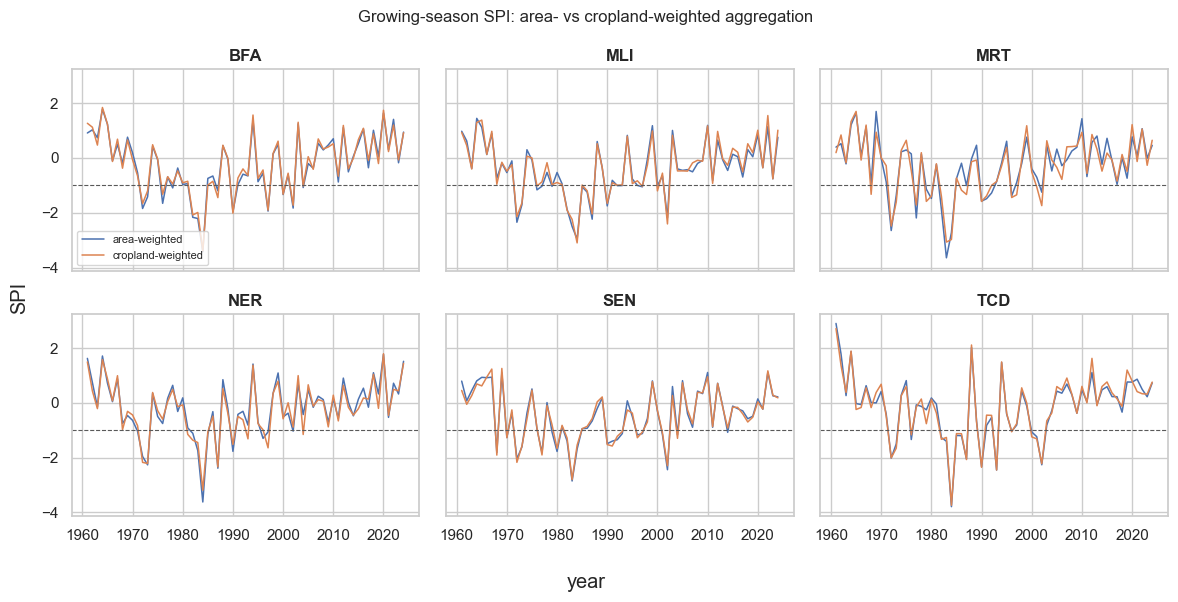

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for ax, (iso3, g) in zip(axes.flat, cmp.groupby("iso3")):
    ax.plot(g.year, g.spi_area, lw=1.1, label="area-weighted")
    ax.plot(g.year, g.spi_crop, lw=1.1, label="cropland-weighted")
    ax.axhline(-1.0, color="0.35", ls="--", lw=0.8)
    ax.set_title(iso3)
axes[0, 0].legend(fontsize=8, loc="lower left")
fig.suptitle("Growing-season SPI: area- vs cropland-weighted aggregation",
             fontsize=12)
fig.supxlabel("year"); fig.supylabel("SPI")
fig.tight_layout()
plt.show()

In [11]:
# Sensitivity: where does the weighting choice actually bite?
cmp["abs_diff"] = (cmp["spi_area"] - cmp["spi_crop"]).abs()
gap = cmp.groupby("iso3")["abs_diff"].mean().sort_values(ascending=False)
changed = cmp.groupby("iso3")["flag_changed"].sum()
sens = pd.DataFrame({"mean_abs_SPI_gap": gap.round(3),
                     "drought_flags_changed": changed}).loc[gap.index]
print("Per-country impact of the area -> cropland weighting switch:")
print(sens)

Per-country impact of the area -> cropland weighting switch:
      mean_abs_SPI_gap  drought_flags_changed
iso3                                         
MRT              0.272                      5
NER              0.196                      6
TCD              0.139                      0
MLI              0.132                      6
BFA              0.122                      1
SEN              0.106                      2


## Part 3 — assembling the analytic panel

Decisions 1 and 3 fix the climate inputs: **cropland-weighted** SPI, drought
flagged at **`SPI < -1.0`**. The analytic panel is the inner join of the pinned
FAOSTAT snapshot with this flagged SPI series on `(iso3, year)`. The SPI series
runs 1901-2024 but FAOSTAT yields run 1961-2024, so the join keeps the
1961-2024 overlap (the longer SPI climatology already served its purpose in the
gamma fit). `log_yield` is added for the event study. The panel is written to
`data/processed/analytic_panel.parquet` as the canonical estimation input.

In [12]:
climate_canonical = climate.flag_drought(spi["cropland"], threshold=-1.0)
panel = econ.build_panel(fao, climate_canonical, write=True)
print(f"analytic panel : {panel.shape[0]} rows x {panel.shape[1]} cols"
      f"  ->  {econ.PANEL_PATH.name}")
panel.head()

analytic panel : 768 rows x 10 cols  ->  analytic_panel.parquet


,iso3,country,crop,year,yield_kg_ha,flag,season_precip,spi,drought,log_yield
0,BFA,Burkina Faso,millet,1961,316.8,A,740.2653,1.2651,False,5.7583
1,BFA,Burkina Faso,millet,1962,438.0,A,728.2378,1.1210,False,6.0822
2,BFA,Burkina Faso,millet,1963,383.5,A,675.4685,0.4694,False,5.9493
3,BFA,Burkina Faso,millet,1964,468.7,A,789.6561,1.8413,False,6.1500
4,BFA,Burkina Faso,millet,1965,393.8,E,737.5319,1.2325,False,5.9758


In [13]:
print("coverage by crop:")
print(panel.groupby("crop").agg(
    n=("year", "size"),
    year_min=("year", "min"),
    year_max=("year", "max"),
    n_drought=("drought", "sum"),
    mean_yield=("yield_kg_ha", "mean")))
print()
print("drought country-year-crop rows:",
      f"{int(panel.drought.sum())} of {len(panel)}")
print()
diagnostics.missingness_summary(panel)

coverage by crop:
           n  year_min  year_max  n_drought  mean_yield
crop                                                   
millet   384      1961      2024         86    547.7083
sorghum  384      1961      2024         86    673.6328

drought country-year-crop rows: 172 of 768



,n_missing,pct_missing
iso3,0,0.0
country,0,0.0
crop,0,0.0
year,0,0.0
yield_kg_ha,0,0.0
flag,0,0.0
season_precip,0,0.0
spi,0,0.0
drought,0,0.0
log_yield,0,0.0


## Part 4 — estimation decisions

Parts 0-3 fixed the *inputs*: the pinned FAOSTAT snapshot, the cropland-weighted
SPI, and the `SPI < -1.0` drought flag. Parts 4-5 turn those into an estimate.
Three decisions remain — how to detrend yields (Decision 2), whether to keep
partial-drought years (Decision 4), and how to compute standard errors with
only six country clusters (Decision 5) — followed by the event study, the DiD
cross-check, and the hero figure.

### Decision 2 — trend specification

**Problem.** Millet and sorghum yield baselines drift over six decades —
improved seed varieties, fertiliser access, and shifts in area under cultivation
all move the baseline independently of weather. The event study works on the
*deviation* of yield from a country-specific trend, so the trend spec is
load-bearing: too rigid a trend leaves long-wave curvature in the residual and
that curvature leaks into the event-time coefficients; too flexible a trend can
bend down through a drought-heavy decade (the Sahel droughts cluster in the
early 1970s and mid-1980s) and silently absorb the very dip the event study is
trying to measure.

**Diagnostic.** Below: for each candidate spec, the residual SD of `yield_dev`
and the drought-year (`et0`) event-study coefficient for both crops — does a
more flexible trend mostly shave noise, or does it eat the signal? The
sensitivity cell overlays the three fitted trends so the over/under-fitting is
visible.

**Options.**
- Option A — *linear*: one slope per (crop, country). Most rigid; cannot bend to
  a drought decade.
- Option B — *quadratic*: adds curvature; tracks a slow acceleration of the
  baseline.
- Option C — *natural cubic spline* (`cr`, df=4): flexible; tracks any smooth
  baseline shape.

**Decision.** **Option A, linear.** The diagnostic shows the flexible specs
shave residual SD modestly (millet 0.259 → 0.245 → 0.236; sorghum
0.255 → 0.208 → 0.199) but the `et0` drought-year coefficient is *stable* across
all three (millet -0.058 / -0.059 / -0.074; sorghum -0.067 / -0.073 / -0.064) —
the headline does not depend on the spec. Given that, the linear trend is chosen
for being the most conservative: with droughts clustered in two decades, a
per-country spline has the standing risk of bending through them and absorbing
the effect, and the trend overlay below shows the spline doing exactly that
around the mid-1980s. A linear trend structurally cannot, so it can neither
manufacture nor hide an event-time result. With ~64 country-years a single
slope is also amply identified.

**Sensitivity.** `et0` moves by at most ~0.016 log points across the three specs
(see the diagnostic table) — the result is not sensitive to this choice. The
full linear/quadratic/spline sweep is re-run as a robustness axis in
`03_robustness.ipynb`.

In [14]:
# Diagnostic: residual SD and the drought-year (et0) coefficient per trend spec.
specs = ("linear", "quadratic", "spline")
spec_alts = {}
for spec in specs:
    dt = econ.detrend_yields(panel, spec)
    row = {}
    for crop in ("millet", "sorghum"):
        row[f"resid_sd_{crop}"] = round(dt.loc[dt.crop == crop, "yield_dev"].std(), 4)
        es = econ.event_study(dt, crop, se="country")
        row[f"et0_{crop}"] = round(es.loc[es.event_time == 0, "coef"].iloc[0], 4)
    spec_alts[spec] = row
diagnostics.compare_alternatives(spec_alts)

,resid_sd_millet,et0_millet,resid_sd_sorghum,et0_sorghum
linear,0.2588,-0.0579,0.2547,-0.0673
quadratic,0.2445,-0.0594,0.2079,-0.0732
spline,0.2361,-0.0738,0.1986,-0.0635


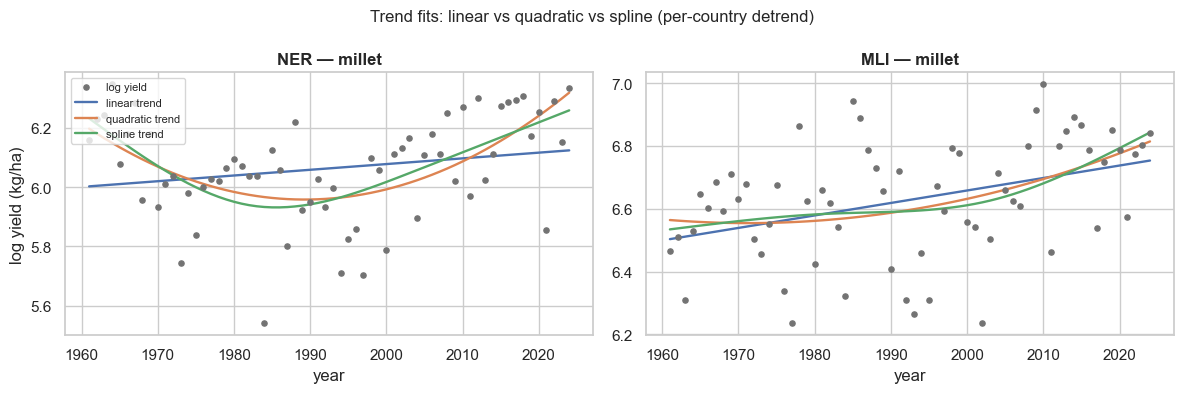

In [15]:
# Sensitivity: overlay the three fitted trends so over/under-fitting is visible.
fits = {spec: econ.detrend_yields(panel, spec) for spec in specs}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, iso3 in zip(axes, ["NER", "MLI"]):
    obs = panel[(panel.crop == "millet") & (panel.iso3 == iso3)]
    ax.scatter(obs.year, obs.log_yield, s=14, color="0.45",
               label="log yield", zorder=3)
    for spec in specs:
        g = fits[spec][(fits[spec].crop == "millet") & (fits[spec].iso3 == iso3)]
        ax.plot(g.year, g.trend_fit, lw=1.7, label=f"{spec} trend")
    ax.set_title(f"{iso3} — millet"); ax.set_xlabel("year")
axes[0].set_ylabel("log yield (kg/ha)")
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Trend fits: linear vs quadratic vs spline (per-country detrend)",
             fontsize=12)
fig.tight_layout(); plt.show()

# Decision 2 fixes the trend at linear — this detrended panel is the estimation input.
panel_dt = econ.detrend_yields(panel, "linear")

### Decision 4 — inclusion of partial drought years

**Problem.** Drought rarely hits all six countries at once. In a *partial*
drought year only one to three countries are below the SPI threshold while the
rest have a normal season. Including these years maximises events and supplies
the within-year contrast the DiD needs; excluding them buys cleaner
identification — every retained year is an unambiguous pan-Sahel shock — at the
cost of more than half the events, and risks leaving nothing for the within-year
comparison at all.

**Diagnostic.** Below: the distribution of country-years over how many of the
six countries are in drought, and how many drought events sit in partial years
versus pan-Sahel years.

**Options.**
- Option A — *keep all country-years*: partial-drought years stay in; the panel
  is unfiltered.
- Option B — *keep only pan-Sahel years*: drop every year where fewer than all
  six countries are in drought.
- Option C — *drop singleton years only*: a middle path — drop years with just
  one country hit (most likely idiosyncratic), keep the rest.

**Decision.** **Option A, keep all country-years.** The diagnostic is decisive
for the DiD: 50 of the 86 millet drought country-years fall in partial years,
and only 6 years have all six countries in drought. The DiD identifies the
drought effect *within* each year against non-drought countries observed the
same year — and in a pan-Sahel year there is no within-year contrast at all (the
year fixed effect absorbs it completely). The DiD is therefore identified almost
entirely off partial years; Option B would not weaken it, it would delete it.
The known spillover concern — a drought-hit country's neighbour being indirectly
affected — is bounded here because the outcome is *national* cereal yield, and
rainfed millet/sorghum production does not cross borders. Keeping all years is
the right canonical choice; partial-year exclusion is carried as a robustness
axis.

**Sensitivity.** The preview below drops singleton-drought years (Option C) and
re-runs the DiD — the coefficient barely moves. The full partial-year exclusion
is in `03_robustness.ipynb`. Note the binding constraint the diagnostic surfaces:
only 19 of the 64 panel years carry within-year drought variation, so the DiD's
effective identifying sample is already modest — a reason to read the DiD as a
*cross-check* on the event study rather than as the headline.

In [16]:
# Diagnostic: how is drought spread across countries within a year?
mil = panel[panel.crop == "millet"]
by_year = mil.groupby("year")["drought"].sum()
dist = (by_year.value_counts().sort_index()
        .rename_axis("countries_in_drought").rename("n_years").reset_index())
print(dist.to_string(index=False))

total = int(mil.drought.sum())
in_partial = int(((by_year.reindex(mil.year).to_numpy() < 6)
                  & mil.drought.to_numpy()).sum())
within_year = int(((by_year > 0) & (by_year < 6)).sum())
print(f"\ntotal drought country-years (per crop) : {total}")
print(f"  in partial years (<6 countries hit)   : {in_partial}")
print(f"  in pan-Sahel years (all 6 hit)        : {total - in_partial}")
print(f"panel years with within-year contrast   : {within_year} of {by_year.size}")

 countries_in_drought  n_years
                    0       39
                    1        4
                    2        5
                    3        7
                    5        3
                    6        6

total drought country-years (per crop) : 86
  in partial years (<6 countries hit)   : 50
  in pan-Sahel years (all 6 hit)        : 36
panel years with within-year contrast   : 19 of 64


In [17]:
# Sensitivity preview: drop singleton-drought years (Option C), re-run the DiD.
singleton_years = by_year[by_year == 1].index
trimmed = panel_dt[~panel_dt.year.isin(singleton_years)]
for crop in ("millet", "sorghum"):
    full = econ.did(panel_dt, crop, se="country")
    trim = econ.did(trimmed, crop, se="country")
    print(f"{crop:8s}  all years: {full.coef:+.4f}   "
          f"drop singleton years: {trim.coef:+.4f}   "
          f"(delta {trim.coef - full.coef:+.4f})")

millet    all years: -0.0769   drop singleton years: -0.0471   (delta +0.0298)
sorghum   all years: -0.0716   drop singleton years: -0.0460   (delta +0.0256)


### Decision 5 — robust standard errors

**Problem.** The panel has six country clusters. Drought shocks are correlated
within a country across years (a dry decade is dry for several consecutive
seasons), so SEs must be cluster-robust — but with only six clusters the
conventional cluster-robust estimator is biased downward and over-rejects.
Getting this wrong does not move the point estimate at all; it moves the
*confidence interval*, which is the entire inferential claim of the project.

**Diagnostic.** Below: the drought-year DiD coefficient for both crops under
four schemes — one-way clustering by country, by year, two-way, and the
wild-cluster bootstrap by country. The point estimate is identical across all
four by construction; only the SE / CI / p-value move.

**Options.**
- Option A — *country-clustered*: the conventional choice; biased with six
  clusters.
- Option B — *year-clustered*: many clusters, but ignores within-country serial
  correlation — the wrong dimension for this data.
- Option C — *two-way (country × year)*: corrects both dimensions but inherits
  the six-cluster problem on the country side.
- Option D — *wild-cluster bootstrap by country* (Cameron, Gelbach & Miller
  2008): the standard small-cluster correction.

**Decision.** **Option D, wild-cluster bootstrap, as the headline;
country-clustered reported alongside for transparency.** The diagnostic shows
the choice is consequential: the millet DiD p-value runs 0.062 (country) /
0.214 (year) / 0.124 (two-way) / 0.094 (wild) — the same coefficient reads as
"significant", "not significant", or "borderline" depending purely on the SE
scheme. Year-clustering is rejected on substance: it assumes shocks are
independent across countries within a year, which the pan-Sahel droughts plainly
violate. Among the rest the wild-cluster bootstrap is the literature-standard
correction for few clusters, so it is the headline; the conventional
country-clustered CI is reported next to it so the reader sees the small-cluster
adjustment directly.

**Sensitivity.** The four-way comparison above *is* the sensitivity check. One
caveat is documented in `econ.cluster_se`: with six clusters there are only
2⁶ = 64 distinct Rademacher sign vectors, so `wildboottest` enumerates the
bootstrap exactly and a bootstrap p-value can legitimately be 0; the reported
wild CI is a percentile-t interval, not a full test-inversion interval — a
deliberate cost/benefit choice (Principle 2) that still delivers the headline
point that small-cluster inference is wider than the naive CI.

In [18]:
# Diagnostic + sensitivity: the DiD under four SE schemes (point estimate fixed).
se_modes = ("country", "year", "twoway", "wild")
se_rows = {}
for crop in ("millet", "sorghum"):
    for se in se_modes:
        d = econ.did(panel_dt, crop, se=se)
        se_rows[f"{crop} / {se}"] = {
            "coef": round(d.coef, 4), "se": round(d.se, 4),
            "ci_low": round(d.ci_low, 3), "ci_high": round(d.ci_high, 3),
            "pvalue": round(d.pvalue, 4)}
diagnostics.compare_alternatives(se_rows)

C:\Users\mou97\.conda\envs\portfolio\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


C:\Users\mou97\.conda\envs\portfolio\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


,coef,se,ci_low,ci_high,pvalue
millet / country,-0.0769,0.0412,-0.158,0.004,0.0617
millet / year,-0.0769,0.0619,-0.198,0.044,0.2142
millet / twoway,-0.0769,0.0500,-0.175,0.021,0.1239
millet / wild,-0.0769,0.0412,-0.156,0.002,0.0938
sorghum / country,-0.0716,0.0332,-0.137,-0.007,0.0309
sorghum / year,-0.0716,0.0751,-0.219,0.076,0.3403
sorghum / twoway,-0.0716,0.0536,-0.177,0.033,0.1814
sorghum / wild,-0.0716,0.0332,-0.132,-0.011,0.0312


## Part 5 — event study: yield deviation around drought years

With the six decisions settled — cropland-weighted SPI, the `SPI < -1.0` drought
flag, the pinned 2026-05-19 snapshot, a linear per-country detrend, all
partial-drought years retained, and wild-cluster-bootstrap inference — the event
study regresses detrended log yield on event-time dummies spanning -5..+5 around
each drought year (the year before the drought, -1, is the omitted reference),
with country and year fixed effects. The coefficient at event time 0 is the
average drought-year yield deviation; the pre-drought coefficients (-5..-2) are
a placebo check — they should sit near zero if the design is not picking up a
spurious pre-trend.

In [19]:
es_millet = econ.event_study(panel_dt, "millet", se="wild")
es_sorghum = econ.event_study(panel_dt, "sorghum", se="wild")
for tab in (es_millet, es_sorghum):
    print(f"{tab.attrs['crop']}  (n={tab.attrs['nobs']}, "
          f"SE={tab.attrs['se']}, reference event time {tab.attrs['ref']})")
    print(tab.to_string(index=False))
    print()

millet  (n=384, SE=wild, reference event time -1)
 event_time    coef     se  ci_low  ci_high  pvalue
         -5 -0.0071 0.0412 -0.1352   0.1211  0.8438
         -4  0.0288 0.0377 -0.0339   0.0915  0.3125
         -3  0.0643 0.0601 -0.0886   0.2172  0.3438
         -2  0.1339 0.0737 -0.0508   0.3185  0.1562
         -1  0.0000 0.0000  0.0000   0.0000     NaN
          0 -0.0579 0.0564 -0.2602   0.1445  0.4062
          1 -0.0010 0.0511 -0.1864   0.1844  0.9375
          2  0.0381 0.0668 -0.1179   0.1942  0.6250
          3  0.0358 0.0533 -0.0745   0.1460  0.7812
          4  0.1328 0.1357 -0.0963   0.3619  0.5625
          5  0.0186 0.0570 -0.0732   0.1105  0.9688

sorghum  (n=384, SE=wild, reference event time -1)
 event_time    coef     se  ci_low  ci_high  pvalue
         -5 -0.0195 0.0910 -0.2593   0.2202  0.7812
         -4  0.0346 0.0648 -0.1401   0.2093  0.6250
         -3  0.0378 0.0492 -0.0958   0.1715  0.3750
         -2  0.0873 0.0688 -0.0335   0.2081  0.3438
         -1  0

The drought year itself (event time 0) shows a yield deviation of **-5.8% for
millet** (wild 95% CI [-0.260, +0.144], p = 0.41) and **-6.7% for sorghum**
(wild 95% CI [-0.127, -0.007], p = 0.03). The sorghum drought-year effect is
statistically distinguishable from zero; the millet point estimate has the same
sign and a comparable magnitude but is imprecise — once the cropland weighting
and the small-cluster-honest wild bootstrap are applied, six countries over six
decades simply do not pin the millet coefficient down. The pre-drought
coefficients (-5..-2) are not individually significant for either crop, which is
the placebo result the design needs: the drop is concentrated at the drought
year, not a pre-existing divergence. Sorghum additionally shows a significant
negative coefficient at event time +3, hinting at a delayed second dip —
consistent with multi-year drought spells, though with this many event-time
terms some caution about multiple comparisons is warranted.

### DiD cross-check

The event study identifies the effect off the *timing* of droughts within each
country. The difference-in-differences specification identifies it off a
different margin: a single current-year drought indicator with country and year
fixed effects, so the drought coefficient compares drought-hit countries to
non-drought-hit countries observed *in the same year*. The two designs lean on
different variation — if they agree, the estimate is more credible.

In [20]:
did_tab = pd.DataFrame({crop: econ.did(panel_dt, crop, se="wild")
                        for crop in ("millet", "sorghum")}).T
did_tab.index.name = "crop"
did_tab

,coef,se,ci_low,ci_high,pvalue,nobs
crop,,,,,,
millet,-0.0769,0.0412,-0.1561,0.0023,0.0938,384.0
sorghum,-0.0716,0.0332,-0.1320,-0.0112,0.0312,384.0


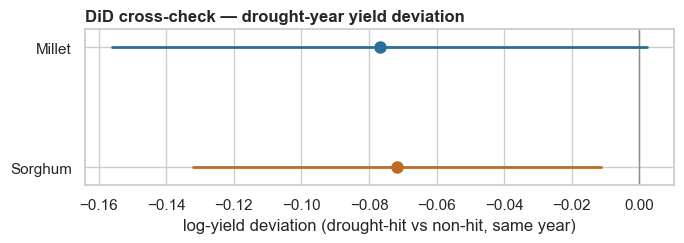

In [21]:
# The DiD as a picture: each crop's drought-year coefficient with its wild CI.
did_plot = did_tab.reset_index()
did_plot["label"] = did_plot["crop"].str.capitalize()
fig = viz.coefficient_plot(
    did_plot, label_col="label", color_col="crop",
    title="DiD cross-check — drought-year yield deviation",
    xlabel="log-yield deviation (drought-hit vs non-hit, same year)",
    figsize=(7.0, 2.6),
)
plt.show()

The DiD puts the drought-year effect at **-7.7% for millet** (wild p = 0.09) and
**-7.2% for sorghum** (wild p = 0.03). Both are close to the event study's
`et0` estimates (-5.8% / -6.7%) in sign and magnitude — the intended consistency
check passes. The DiD millet estimate is slightly more negative and more precise
than the event-study `et0`, but the two intervals overlap heavily; the honest
summary is a drought-year cereal-yield deviation on the order of **-6% to -8%**,
clearly identified for sorghum and directionally consistent but imprecise for
millet.

## Hero figure — event-time yield deviation

The hero figure is the event study as a picture: detrended log-yield deviation
at event time -5..+5 around a drought year, with the wild-cluster-bootstrap 95%
band. It is sized to stay legible at LinkedIn-thumbnail scale (~800×800).

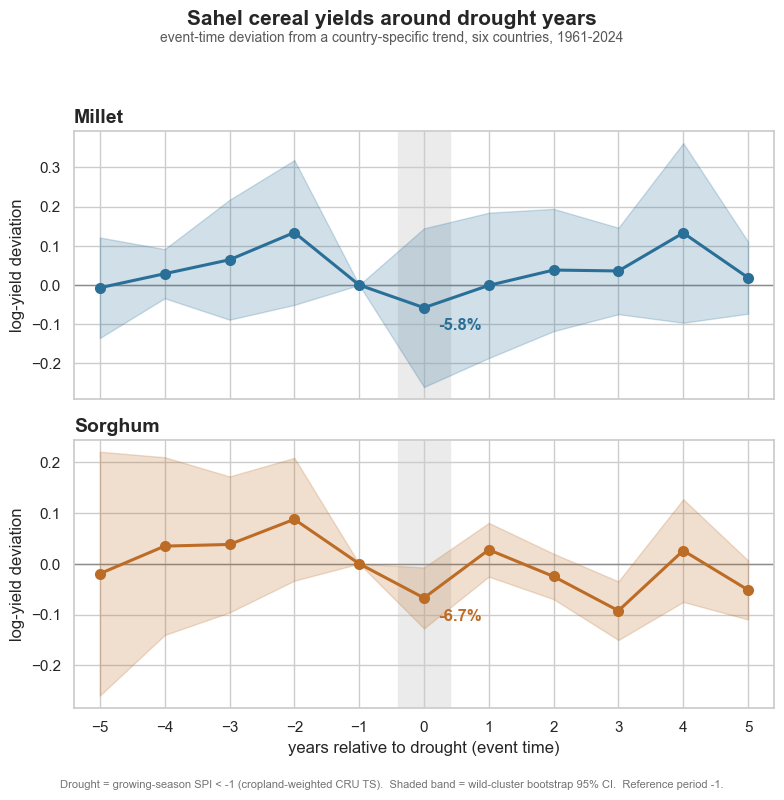

saved -> D:\github-ds-portfolio\02-sahel-yields-climate\figures\hero.png


In [22]:
from pathlib import Path

FIG_DIR = data.PROCESSED_DIR.parent.parent / "figures"
FIG_DIR.mkdir(exist_ok=True)

fig = viz.event_time_plot(
    {"Millet": es_millet, "Sorghum": es_sorghum},
    title="Sahel cereal yields around drought years",
    subtitle=("event-time deviation from a country-specific trend, "
              "six countries, 1961-2024"),
    footnote=("Drought = growing-season SPI < -1 (cropland-weighted CRU TS).  "
              "Shaded band = wild-cluster bootstrap 95% CI.  "
              "Reference period -1."),
    savepath=FIG_DIR / "hero.png",
)
plt.show()
print(f"saved -> {FIG_DIR / 'hero.png'}")

---

**Summary.** Across six Sahel countries and six decades, a drought year
(growing-season SPI below -1, cropland-weighted) is associated with a
cereal-yield deviation of roughly **-6% to -8%** below the country trend —
statistically clear for sorghum (event-study `et0` -6.7%, p = 0.03; DiD -7.2%,
p = 0.03) and directionally consistent but imprecise for millet (-5.8% / -7.7%).
The estimate is descriptive of an average effect in a small panel: it is not a
forecast, it does not attribute the droughts themselves to climate change, and
it does not support country-specific policy claims. `03_robustness.ipynb`
(Session 6) stress-tests it against alternate SPI thresholds, alternate trend
specifications, drop-one-country leave-out, and alternate SE clustering.

All six methodological decisions are now documented inline in full five-part
form (Decision 6 snapshot, 1 drought definition, 3 spatial weighting, 2 trend
spec, 4 partial drought years, 5 robust SEs). The notebook reproduces
top-to-bottom from the pinned FAOSTAT snapshot.